### DCE Soymeal: Curve vs Outright
Every trade is in M1 (the most-traded contract), using signals from the shape of the curve against M2 and M3 (the next two expiries). Decided at the close, held from the next day.

**Curve baseline trade.** Trades the curve's state. Short M1 when the curve is in contango and the M1–M2 spread has weakened over the last 5 days; long otherwise. Stands aside on days when the divergence trade points the other way. In the market about 90% of the time.

**Divergence trade (lead-lag).** The curve tends to move before the outright. If the front of the curve has firmed against M2 and M3 over 5 days but M1 hasn't rallied, go long; the reverse, go short.
- Small divergences (fast leg): held 1 day.
- Large divergences (slow leg): held 5 days.

**Combined book.** Both positions netted into one M1 position.

| | Net Sharpe | Before Jul 2022 | After Jul 2022 |
|---|---|---|---|
| Curve baseline | 1.28 | 1.43 | 1.15 |
| Divergence | 1.79 | 3.07 | 0.91 |
| Combined | 1.80 | 2.49 | 1.30 |

Jun 2019 – Sep 2026, net of 3.5 bps per side.

In [6]:
from sklearn.model_selection import GridSearchCV
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from theme import set_theme
set_theme()

import akshare as ak
import utilities as ut
import lead_lag as ll
import lead_lag_plots as llp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# run strategy analysis for DCE Meal
path = r"C:\Users\Amin\PycharmProjects\Asia Ags\data\raw\dce_meal_data.parquet"

results = ll.run(ll.Config(data_path=path))
results["metrics"]

,fast,slow,lead_lag,baseline_curve_state,combined_1to1
sharpe_net,0.729578,1.623422,1.793543,1.277202,1.799042
sharpe_gross,0.963396,1.730979,1.966048,1.444178,1.986854
ann_return_%,3.880536,20.271366,24.387102,23.238519,48.017620
ann_vol_%,5.318880,12.486811,13.597169,18.194864,26.690658
max_drawdown_%,-6.207431,-18.782427,-16.060155,-18.322793,-21.141825
return_over_dd,0.625144,1.079273,1.518485,1.268285,2.271215
time_in_market,0.081111,0.401111,0.446667,0.901111,0.896667
trades_per_year,17.920000,17.640000,35.840000,37.800000,72.520000
trade_win_rate,0.703125,0.634921,0.664062,0.503704,0.552124
avg_trade_bps,25.154776,117.194818,70.231869,63.059044,67.145367


<Axes: title={'left': 'Trade outcomes: slow'}, xlabel='net return per trade, bps', ylabel='trades'>

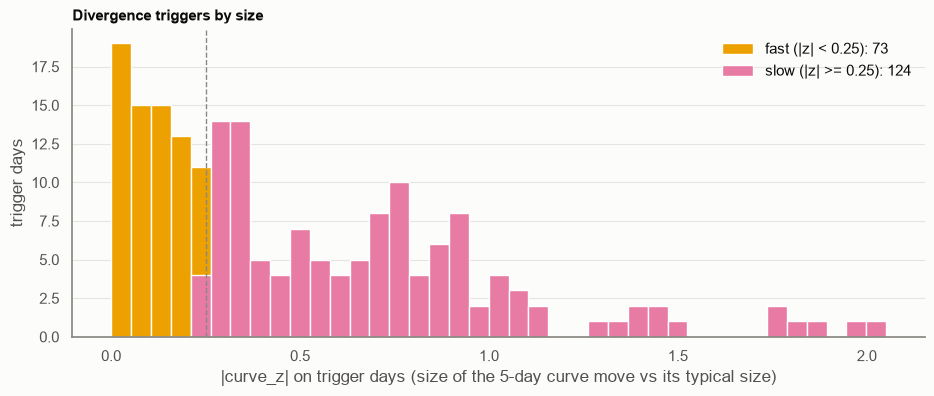

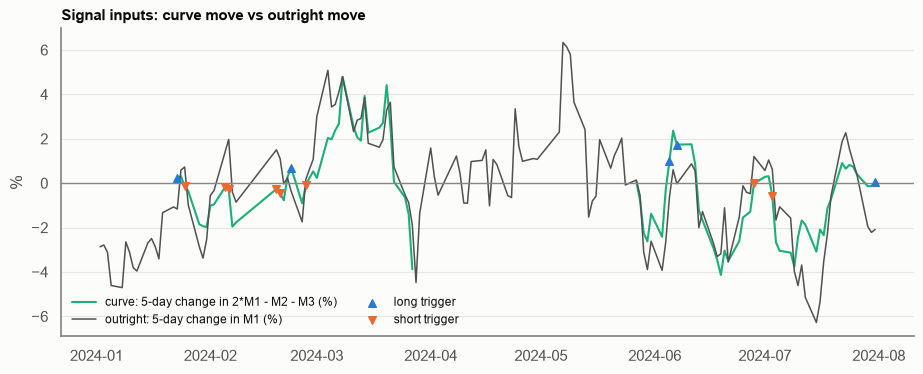

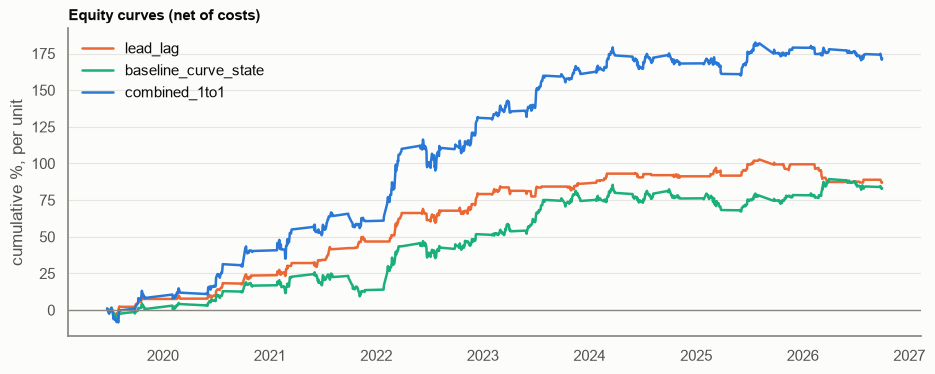

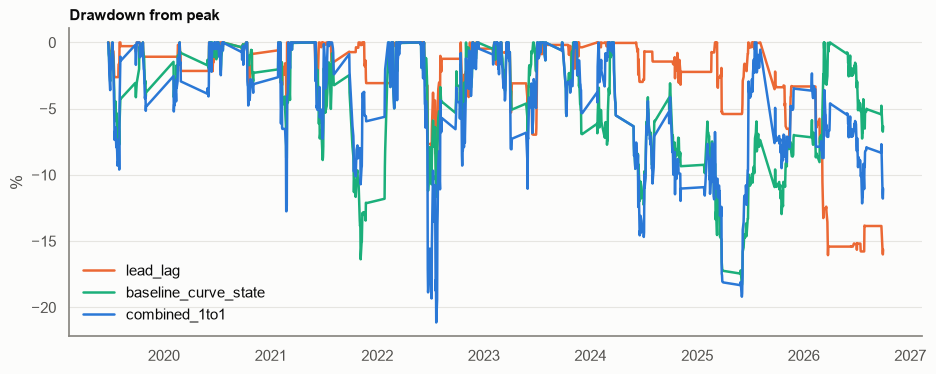

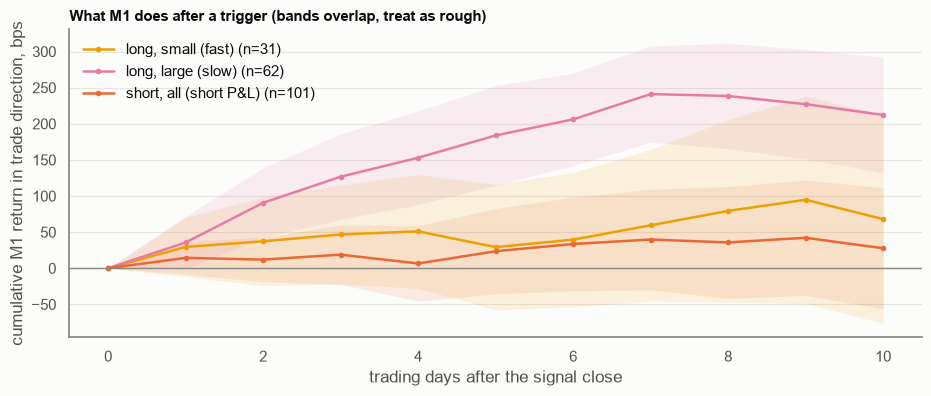

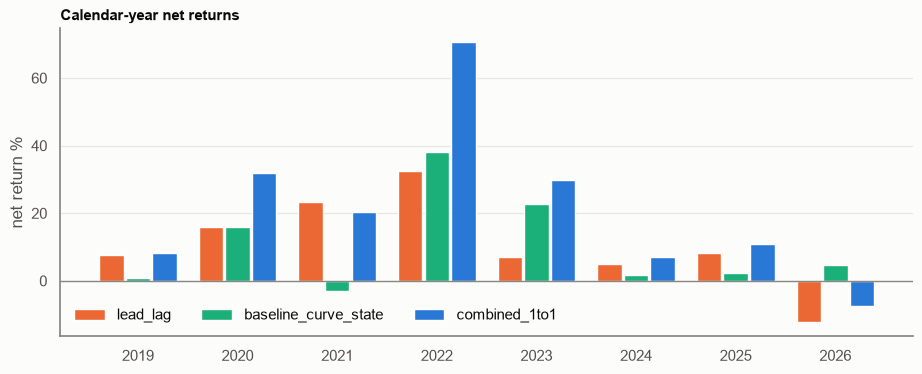

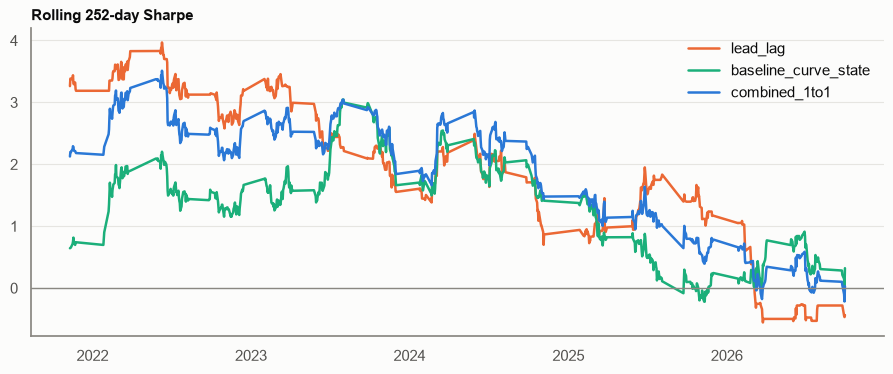

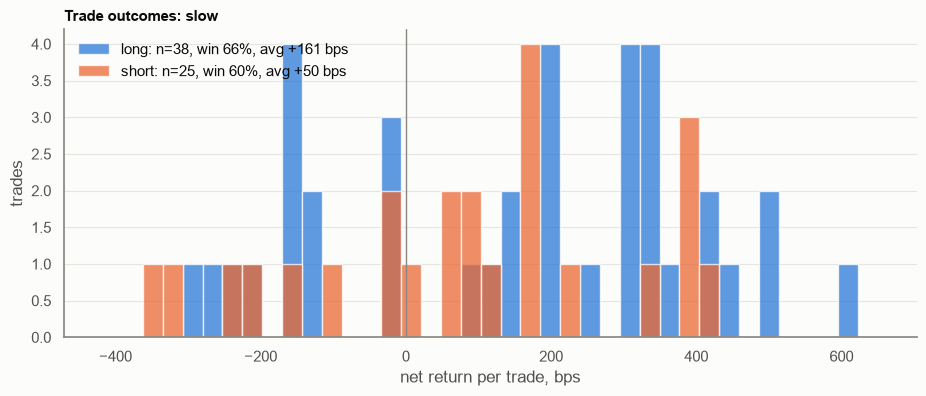

In [10]:
# visualizations

llp.plot_signal_distribution(results)
llp.plot_signal_inputs(results, start="2024-01-01", end="2024-07-31")
llp.plot_equity(results)
llp.plot_drawdown(results)
llp.plot_event_study(results)
llp.plot_yearly(results)
llp.plot_rolling_sharpe(results)
llp.plot_trade_returns(results, book="slow")